# PandaX-4T efficiency model

PRD 110 023029 Eq. (16) factorizes the signal efficiency into

$$\epsilon(\xi) = \epsilon_{quality}(\xi)\;\epsilon_{ROI}(\xi)\;\epsilon_{recon}(\xi)\;\epsilon_{SS}(\xi).$$

This notebook builds and validates the diamx efficiency model end to end:

1. **Project** the S1/S2 cut acceptances (`s1_cut_acc` x `s2_cut_acc`, Fig. 12) onto recoil energy (with the S1-only / S2-only breakdown).
2. **Derive** the residual energy-dependent quality term $r(\xi)=\epsilon^{Fig.15}_{quality}(\xi)/\epsilon^{cut}_q(\xi)$ and write it -- and the reconstruction efficiency -- as appletree maps.
3. **Wire-in** check: the chain weight `eff = cut_acc_s1 * cut_acc_s2 * r(xi) * eps_recon(xi)` must reproduce quality x reconstruction.
4. **Total** efficiency: apply the S1/S2-size ROI by hand and compare to the digitized Fig. 15 total median.

So quality = (S1/S2 cut acc) x $r(\xi)$; reconstruction = $\epsilon_{recon}(\xi)$; single-scatter = 1 (single scatters only); ROI = the (cs1, cs2_b) size selection. Digitized inputs live in `diamx/data/pandax4t_run{0,1}_eff_{er,nr}_{quality,rec,total_median}.csv`.

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import appletree as apt
import diamx
from diamx.appletree import get_file_path_diamx
from diamx.appletree.components.pandax4t import NRPandaX4T, ERFlatPandaX4T

DATA = os.path.join(os.path.dirname(diamx.__file__), 'data')
MAPS = os.path.join(os.path.dirname(diamx.__file__), 'appletree', 'maps')
N_EVENTS = 4_000_000

def write_point_map(json_name, x, y, coord='energy'):
    x = np.asarray(x, float); o = np.argsort(x)
    json.dump({'coordinate_system': x[o].tolist(), 'coordinate_type': 'point',
               'coordinate_name': coord, 'map': np.clip(np.asarray(y, float)[o], 0, 1).tolist()},
              open(os.path.join(MAPS, json_name), 'w'))
# project over (slightly beyond) the digitized energy range of each recoil
ERANGE = {'nr': (0.5, 125.0), 'er': (0.1, 40.0)}
COMP   = {'nr': NRPandaX4T, 'er': ERFlatPandaX4T}

def _ok(s):
    try: get_file_path_diamx(s); return True
    except Exception: return False
def subst(cfg):
    out = {}
    for k, v in cfg.items():
        if isinstance(v, list): out[k] = [get_file_path_diamx(e) if _ok(e) else e for e in v]
        elif isinstance(v, str): out[k] = get_file_path_diamx(v) if _ok(v) else v
        else: out[k] = v
    return out

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform


/home/mhliu/Documents/private_nt_aux_files/ntauxfiles/interface.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Using aptext package from https://github.com/XENONnT/applefiles


/home/mhliu/Documents/appletree/appletree/__init__.py:54: UserWarning: You are running appletree on CPU, which usually results in low performance.
  warn(warning)


## Project the S1/S2 cut-acceptance product onto recoil energy

In [2]:
def project_cutacc(run, recoil):
    lo, hi = ERANGE[recoil]
    with open(get_file_path_diamx(f'pandax4t_{run}_{recoil}.json')) as f:
        instruct = json.load(f)
    instruct.update({'lower_energy': lo, 'upper_energy': hi})
    pm = apt.Parameter(get_file_path_diamx(f'pandax4t_{run}_{recoil}_par.json')); pm.sample_prior()
    params = dict(pm.get_all_parameter())
    with open(get_file_path_diamx(f'pandax4t_{run}_{recoil}_model.json')) as f:
        params.update(json.load(f))
    for s in ('elife_sigma', 's1_cut_acc_sigma', 's2_cut_acc_sigma'):
        params[s] = 0.0
    want = ['energy', 'cut_acc_s1', 'cut_acc_s2']
    tag = f'eff_{run}_{recoil}'
    comp = COMP[recoil](tag, llh_name=tag)
    comp.deduce(data_names=want, force_no_eff=True)
    dc = {}
    for pn, _, _ in comp.worksheet:
        for cn, cf in eval(f'apt.plugins.{pn}').takes_config.items():
            try: dc[cn] = cf.get_default()
            except ValueError: pass
    dc.update(instruct)
    apt.share.clear_cache(); comp.set_config(subst(dc))
    comp.deduce(data_names=want, force_no_eff=True); comp.compile()
    key = apt.get_key(); key, (e, ca1, ca2) = comp.simulate(key, N_EVENTS, params)
    return np.asarray(e), np.asarray(ca1), np.asarray(ca2)

def cutacc_curve(e, y, lo, hi, nb=90):
    edges = np.linspace(lo, hi, nb); idx = np.digitize(e, edges) - 1
    ctr = 0.5 * (edges[:-1] + edges[1:])
    m = np.array([y[idx == k].mean() if (idx == k).sum() > 300 else np.nan for k in range(len(ctr))])
    return ctr, m

col = {'run0': 'tab:blue', 'run1': 'tab:orange'}
# proj[(run,rec)] = (energy_centers, product, s1_only, s2_only) cut-acc curves
proj = {}
for run in ('run0', 'run1'):
    for rec in ('er', 'nr'):
        e, ca1, ca2 = project_cutacc(run, rec); lo, hi = ERANGE[rec]
        ctr, prod = cutacc_curve(e, ca1 * ca2, lo, hi)
        _, s1 = cutacc_curve(e, ca1, lo, hi); _, s2 = cutacc_curve(e, ca2, lo, hi)
        proj[(run, rec)] = (ctr, prod, s1, s2)
        print(f'{run} {rec}: projected cut-acc <eff>={np.nanmean(prod):.3f}')

/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


eff_run0_er's map s2_cut_acc is using the parameter s2_cut_acc_sigma.
eff_run0_er's map s1_cut_acc is using the parameter s1_cut_acc_sigma.
run0 er: projected cut-acc <eff>=0.979
eff_run0_nr's map s2_cut_acc is using the parameter s2_cut_acc_sigma.
eff_run0_nr's map s1_cut_acc is using the parameter s1_cut_acc_sigma.


/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


run0 nr: projected cut-acc <eff>=0.971
eff_run1_er's map s2_cut_acc is using the parameter s2_cut_acc_sigma.
eff_run1_er's map s1_cut_acc is using the parameter s1_cut_acc_sigma.


/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


run1 er: projected cut-acc <eff>=0.969
eff_run1_nr's map s2_cut_acc is using the parameter s2_cut_acc_sigma.
eff_run1_nr's map s1_cut_acc is using the parameter s1_cut_acc_sigma.


/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


run1 nr: projected cut-acc <eff>=0.954


### S1/S2 cut acceptance projected to energy
The product is the $\epsilon^{cut}_q$ used below; the S1-only / S2-only breakdown shows the **low-energy rolloff is S1-driven**. (This projection also caught the gas_gain < g2_b bug: gas_gain=5 < run1 g2_b=5.03 gave extraction efficiency > 1 and zeroed the run1 S2; now gas_gain=5.5.)

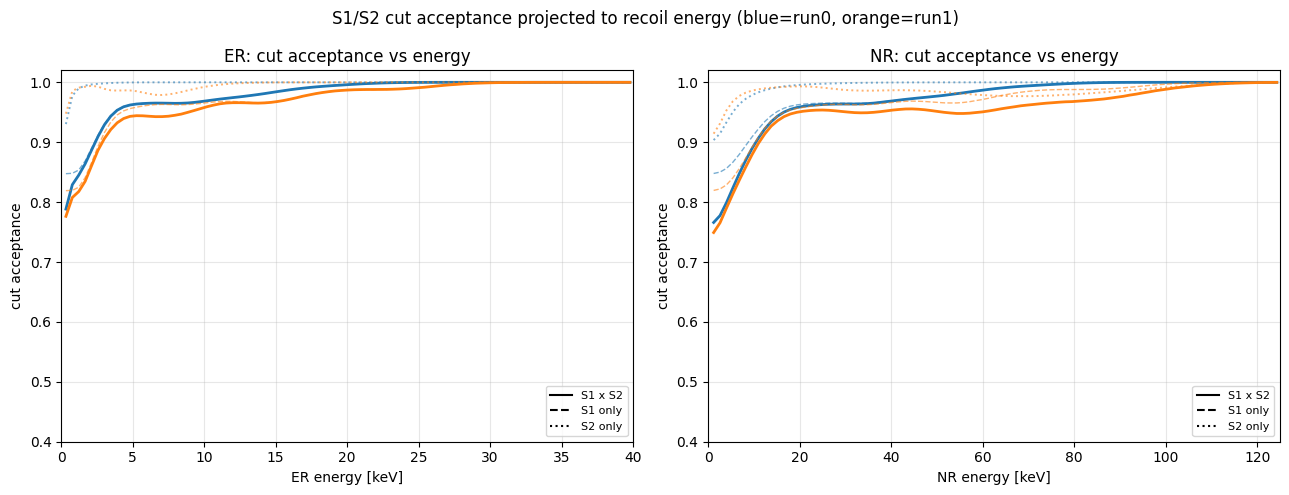

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for j, rec in enumerate(['er', 'nr']):
    for run in ['run0', 'run1']:
        ctr, prod, s1, s2 = proj[(run, rec)]; c = col[run]
        ax[j].plot(ctr, prod, '-', color=c, lw=2)
        ax[j].plot(ctr, s1, '--', color=c, lw=1, alpha=0.6)
        ax[j].plot(ctr, s2, ':', color=c, lw=1.4, alpha=0.6)
    lab = 'ER' if rec == 'er' else 'NR'
    for sty, nm in [('k-', 'S1 x S2'), ('k--', 'S1 only'), ('k:', 'S2 only')]:
        ax[j].plot([], [], sty, label=nm)
    ax[j].set(title=f'{lab}: cut acceptance vs energy', xlabel=f'{lab} energy [keV]',
              ylabel='cut acceptance', ylim=(0.4, 1.02), xlim=(0, ERANGE[rec][1]))
    ax[j].legend(fontsize=8, loc='lower right'); ax[j].grid(alpha=.3)
fig.suptitle('S1/S2 cut acceptance projected to recoil energy (blue=run0, orange=run1)')
fig.tight_layout(); plt.show()

## Derive the residual $r(\xi) = \epsilon^{Fig.15}_{quality} / \epsilon^{cut}_q$ and save it

In [4]:
residual = {}
for run in ('run0', 'run1'):
    for rec in ('er', 'nr'):
        q = np.loadtxt(os.path.join(DATA, f'pandax4t_{run}_eff_{rec}_quality.csv'), delimiter=',')
        qe, qy = q[:, 0], q[:, 1]
        cx, cy = proj[(run, rec)][:2]   # (energy_centers, product)
        good = np.isfinite(cy)
        # interpolate the projected cut-acc onto the digitized quality energies
        cutacc_at_q = np.interp(qe, cx[good], cy[good], left=np.nan, right=np.nan)
        r = qy / cutacc_at_q
        m = np.isfinite(r)
        residual[(run, rec)] = (qe[m], r[m], qy[m], cutacc_at_q[m])
        out = os.path.join(DATA, f'pandax4t_{run}_eff_{rec}_quality_residual.csv')
        np.savetxt(out, np.column_stack([qe[m], r[m]]), delimiter=',')
        # appletree JSON maps consumed by the chain (energy-space):
        #   residual quality r(xi)  and  reconstruction eps_recon(xi)
        write_point_map(f'pandax4t_{run}_eff_{rec}_quality_residual.json', qe[m], r[m])
        rc = np.loadtxt(os.path.join(DATA, f'pandax4t_{run}_eff_{rec}_rec.csv'), delimiter=',')
        write_point_map(f'pandax4t_{run}_eff_{rec}_rec.json', rc[:, 0], rc[:, 1])
        print(f'saved {os.path.basename(out)} + .json + rec.json  ({m.sum()} pts, r[{r[m].min():.3f},{r[m].max():.3f}])')

saved pandax4t_run0_eff_er_quality_residual.csv + .json + rec.json  (95 pts, r[0.599,0.984])
saved pandax4t_run0_eff_nr_quality_residual.csv + .json + rec.json  (100 pts, r[0.473,0.970])
saved pandax4t_run1_eff_er_quality_residual.csv + .json + rec.json  (96 pts, r[0.629,0.987])
saved pandax4t_run1_eff_nr_quality_residual.csv + .json + rec.json  (98 pts, r[0.583,0.989])


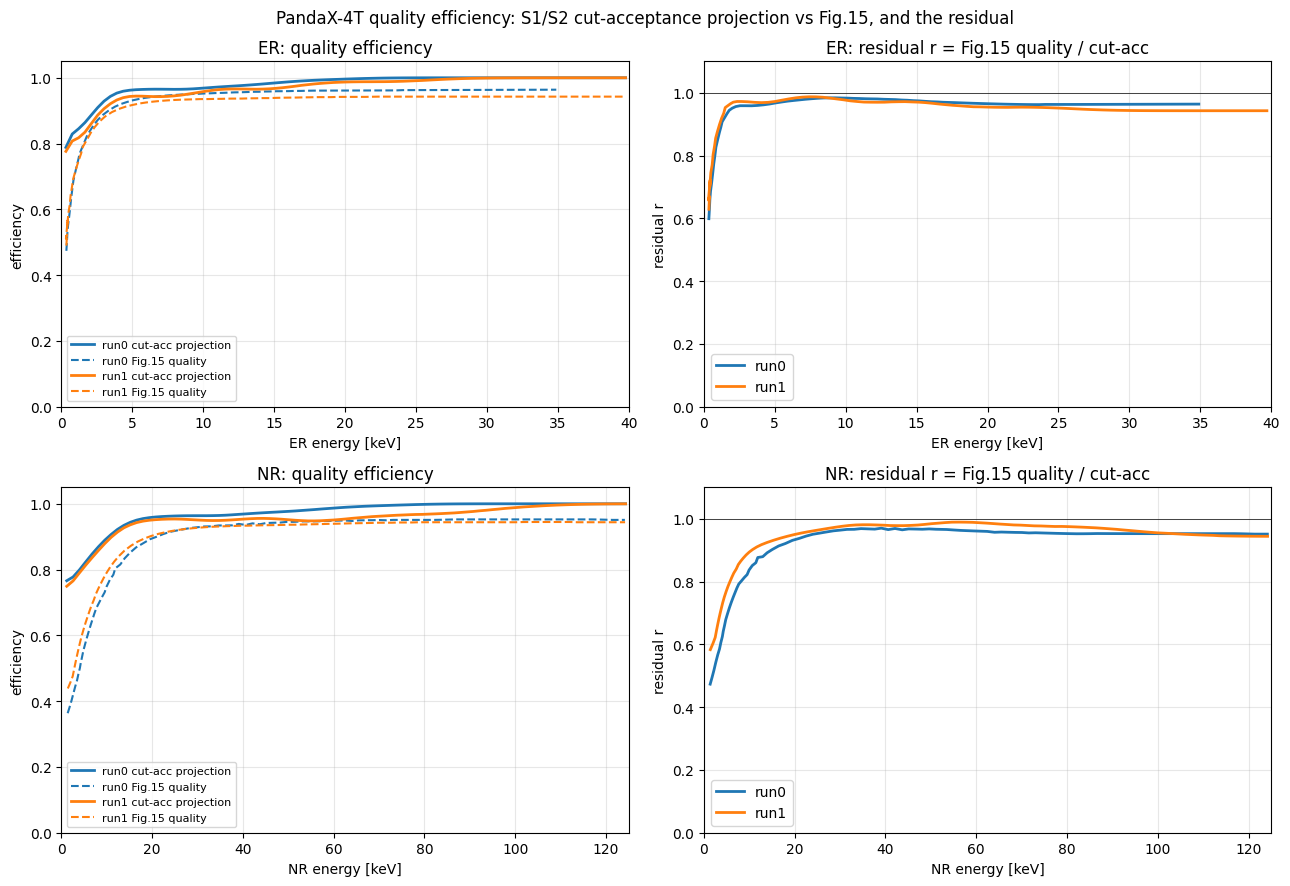

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
for i, rec in enumerate(['er', 'nr']):
    for run in ['run0', 'run1']:
        cx, cy = proj[(run, rec)][:2]; qe, r, qy, ca = residual[(run, rec)]
        c = col[run]
        # left: efficiency comparison
        ax[i,0].plot(cx, cy, '-', color=c, lw=2, label=f'{run} cut-acc projection')
        ax[i,0].plot(qe, qy, '--', color=c, label=f'{run} Fig.15 quality')
        # right: residual
        ax[i,1].plot(qe, r, '-', color=c, lw=2, label=run)
    lab = 'ER' if rec == 'er' else 'NR'
    ax[i,0].set(title=f'{lab}: quality efficiency', xlabel=f'{lab} energy [keV]',
                ylabel='efficiency', ylim=(0, 1.05), xlim=(0, ERANGE[rec][1])); ax[i,0].legend(fontsize=8); ax[i,0].grid(alpha=.3)
    ax[i,1].set(title=f'{lab}: residual r = Fig.15 quality / cut-acc', xlabel=f'{lab} energy [keV]',
                ylabel='residual r', ylim=(0, 1.1), xlim=(0, ERANGE[rec][1])); ax[i,1].axhline(1, color='k', lw=.5); ax[i,1].legend(); ax[i,1].grid(alpha=.3)
fig.suptitle('PandaX-4T quality efficiency: S1/S2 cut-acceptance projection vs Fig.15, and the residual')
fig.tight_layout(); plt.show()

## Wire-in check: project the full chain efficiency
With the residual and reconstruction maps written, the chain's per-event weight is `eff = cut_acc_s1 * cut_acc_s2 * r(xi) * recon(xi)`. Projecting `eff` onto energy must reproduce the digitized **quality x reconstruction** (Eq. 16 with SS=1, ROI via binning).

/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


full_run0_er's map s2_cut_acc is using the parameter s2_cut_acc_sigma.
full_run0_er's map s1_cut_acc is using the parameter s1_cut_acc_sigma.


/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


full_run0_nr's map s2_cut_acc is using the parameter s2_cut_acc_sigma.
full_run0_nr's map s1_cut_acc is using the parameter s1_cut_acc_sigma.


/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


full_run1_er's map s2_cut_acc is using the parameter s2_cut_acc_sigma.
full_run1_er's map s1_cut_acc is using the parameter s1_cut_acc_sigma.


/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


full_run1_nr's map s2_cut_acc is using the parameter s2_cut_acc_sigma.
full_run1_nr's map s1_cut_acc is using the parameter s1_cut_acc_sigma.


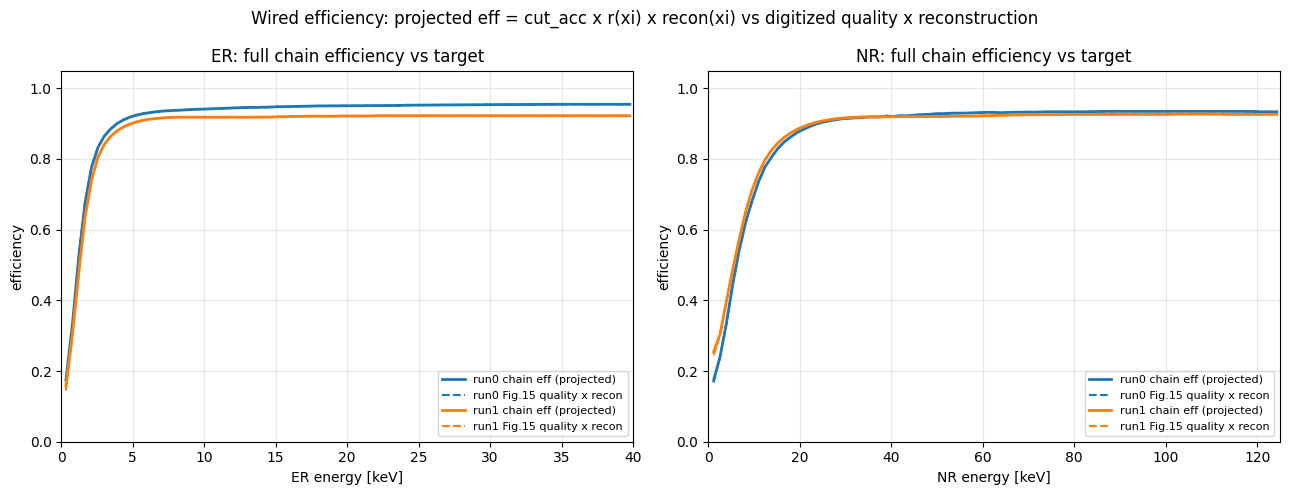

In [6]:
def project_full(run, recoil):
    lo, hi = ERANGE[recoil]
    with open(get_file_path_diamx(f'pandax4t_{run}_{recoil}.json')) as f:
        instruct = json.load(f)
    instruct.update({'lower_energy': lo, 'upper_energy': hi})
    pm = apt.Parameter(get_file_path_diamx(f'pandax4t_{run}_{recoil}_par.json')); pm.sample_prior()
    params = dict(pm.get_all_parameter())
    with open(get_file_path_diamx(f'pandax4t_{run}_{recoil}_model.json')) as f:
        params.update(json.load(f))
    for s in ('elife_sigma', 's1_cut_acc_sigma', 's2_cut_acc_sigma'):
        params[s] = 0.0
    tag = f'full_{run}_{recoil}'
    comp = COMP[recoil](tag, llh_name=tag)
    comp.deduce(data_names=['energy', 'cs1', 'cs2'])   # force_no_eff=False -> +eff
    dc = {}
    for pn, _, _ in comp.worksheet:
        for cn, cf in eval(f'apt.plugins.{pn}').takes_config.items():
            try: dc[cn] = cf.get_default()
            except ValueError: pass
    dc.update(instruct)
    apt.share.clear_cache(); comp.set_config(subst(dc))
    comp.deduce(data_names=['energy', 'cs1', 'cs2']); comp.compile()
    key = apt.get_key(); key, (e, cs1, cs2, eff) = comp.simulate(key, N_EVENTS, params)
    return np.asarray(e), np.asarray(cs1), np.asarray(cs2), np.asarray(eff)

full = {(run, rec): project_full(run, rec)
        for run in ('run0', 'run1') for rec in ('er', 'nr')}

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for j, rec in enumerate(['er', 'nr']):
    for run in ['run0', 'run1']:
        e, cs1, cs2, eff = full[(run, rec)]
        cx, cy = cutacc_curve(e, eff, *ERANGE[rec])
        q = np.loadtxt(os.path.join(DATA, f'pandax4t_{run}_eff_{rec}_quality.csv'), delimiter=',')
        rc = np.loadtxt(os.path.join(DATA, f'pandax4t_{run}_eff_{rec}_rec.csv'), delimiter=',')
        target = np.interp(cx, q[:,0], q[:,1]) * np.interp(cx, rc[:,0], rc[:,1])
        c = col[run]
        ax[j].plot(cx, cy, '-', color=c, lw=2, label=f'{run} chain eff (projected)')
        ax[j].plot(cx, target, '--', color=c, label=f'{run} Fig.15 quality x recon')
    lab = 'ER' if rec == 'er' else 'NR'
    ax[j].set(title=f'{lab}: full chain efficiency vs target', xlabel=f'{lab} energy [keV]',
              ylabel='efficiency', ylim=(0, 1.05), xlim=(0, ERANGE[rec][1])); ax[j].legend(fontsize=8); ax[j].grid(alpha=.3)
fig.suptitle('Wired efficiency: projected eff = cut_acc x r(xi) x recon(xi) vs digitized quality x reconstruction')
fig.tight_layout(); plt.show()

## Total efficiency validation: apply the ROI manually, vs the Fig.15 total
Eq. 16 total = quality x recon x ROI x SS. The chain weight `eff` already carries quality x recon (SS=1); the **ROI** is the S1/S2 size selection $Q_{S1}\in[2,135]$ PE, $Q_{S2b}\in[120,2\times10^4]$ PE. Forming $\epsilon_{tot}(\xi)=\langle\,\mathrm{eff}\cdot\mathbb{1}[\mathrm{ROI}]\mid\xi\rangle$ and comparing to the digitized **total median** tests the detector S1/S2 scale -- in particular the high-energy turn-over where signals exceed the ROI upper bounds -- on top of the (already validated) quality and reconstruction terms.

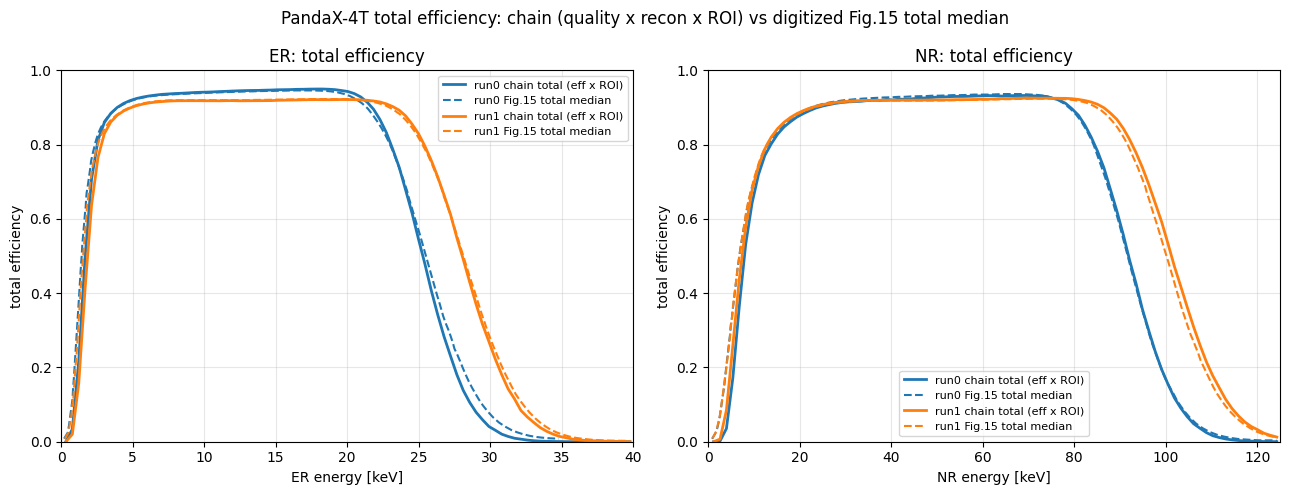

In [7]:
ROI_S1 = (2.0, 135.0); ROI_S2B = (120.0, 2e4)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for j, rec in enumerate(['er', 'nr']):
    for run in ['run0', 'run1']:
        e, cs1, cs2, eff = full[(run, rec)]
        in_roi = (cs1 >= ROI_S1[0]) & (cs1 <= ROI_S1[1]) & (cs2 >= ROI_S2B[0]) & (cs2 <= ROI_S2B[1])
        cx, cy = cutacc_curve(e, eff * in_roi, *ERANGE[rec])
        tot = np.loadtxt(os.path.join(DATA, f'pandax4t_{run}_eff_{rec}_total_median.csv'), delimiter=',')
        c = col[run]
        ax[j].plot(cx, cy, '-', color=c, lw=2, label=f'{run} chain total (eff x ROI)')
        ax[j].plot(tot[:, 0], tot[:, 1], '--', color=c, label=f'{run} Fig.15 total median')
    lab = 'ER' if rec == 'er' else 'NR'
    ax[j].set(title=f'{lab}: total efficiency', xlabel=f'{lab} energy [keV]',
              ylabel='total efficiency', ylim=(0, 1.0), xlim=(0, ERANGE[rec][1])); ax[j].legend(fontsize=8); ax[j].grid(alpha=.3)
fig.suptitle('PandaX-4T total efficiency: chain (quality x recon x ROI) vs digitized Fig.15 total median')
fig.tight_layout(); plt.show()

## Regularize the total-efficiency 1$\sigma$ band (used by `get_eff_uncertainty`)
The Fig. 15 total-efficiency **median** spans the full energy range, but the 1$\sigma$ **band** (lower/upper) is only readable over a middle range -- at the low/high ends the band pinches against the steep turn-on/turn-off and is hard to digitize. Naively interpolating clamps the band to a constant *absolute* value there, which blows up the *relative* band as the median -> 0.

Regularize by holding the **relative** difference constant past the digitized band ends: for energies below the lowest band point use its relative offset, above the highest band point use its relative offset, and reconstruct `lower = median x rel_lo`, `upper = median x rel_hi`. The band then shrinks with the median at the ends. Saved as `pandax4t_run{0,1}_eff_{er,nr}_total_{lower,upper}_reg.csv`.

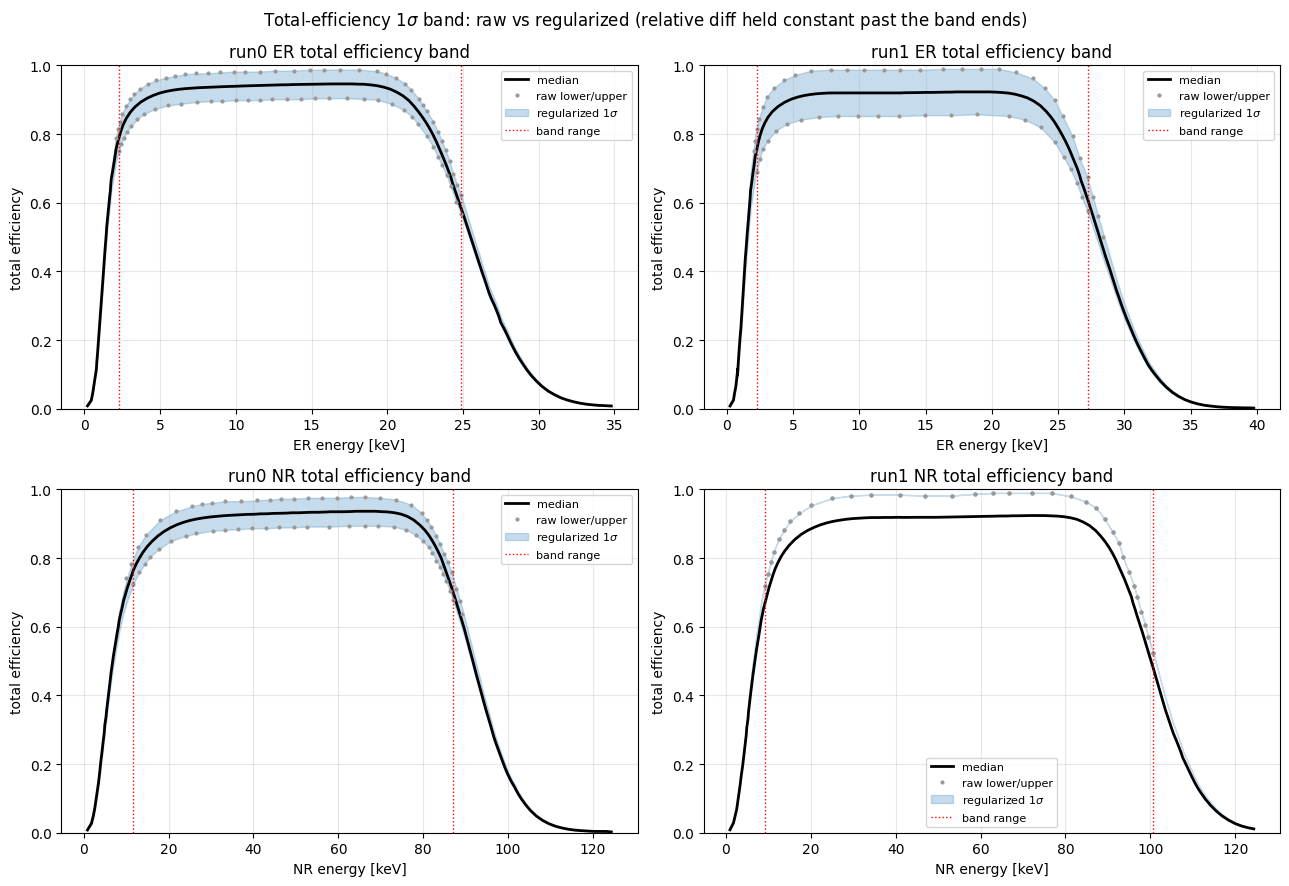

In [8]:
def regularize_band(run, rec):
    g = lambda k: np.loadtxt(os.path.join(DATA, f'pandax4t_{run}_eff_{rec}_total_{k}.csv'), delimiter=',')
    med, lo, up = g('median'), g('lower'), g('upper')
    e, m = med[:, 0], med[:, 1]
    elo = max(lo[:, 0].min(), up[:, 0].min()); ehi = min(lo[:, 0].max(), up[:, 0].max())
    rlo = np.interp(e, lo[:, 0], lo[:, 1]) / m       # relative band on the median grid
    rhi = np.interp(e, up[:, 0], up[:, 1]) / m
    inb = np.where((e >= elo) & (e <= ehi))[0]; i0, i1 = inb[0], inb[-1]
    rlo[:i0] = rlo[i0]; rlo[i1 + 1:] = rlo[i1]       # hold relative diff = lowest/highest band point
    rhi[:i0] = rhi[i0]; rhi[i1 + 1:] = rhi[i1]
    lo_reg, up_reg = m * rlo, m * rhi
    np.savetxt(os.path.join(DATA, f'pandax4t_{run}_eff_{rec}_total_lower_reg.csv'), np.column_stack([e, lo_reg]), delimiter=',')
    np.savetxt(os.path.join(DATA, f'pandax4t_{run}_eff_{rec}_total_upper_reg.csv'), np.column_stack([e, up_reg]), delimiter=',')
    return dict(e=e, m=m, lo=lo, up=up, lo_reg=lo_reg, up_reg=up_reg, elo=elo, ehi=ehi)

band = {(run, rec): regularize_band(run, rec) for run in ('run0', 'run1') for rec in ('er', 'nr')}
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
for i, rec in enumerate(['er', 'nr']):
    for k, run in enumerate(['run0', 'run1']):
        b = band[(run, rec)]; a = ax[i, k]
        a.plot(b['e'], b['m'], 'k-', lw=2, label='median')
        a.plot(b['lo'][:, 0], b['lo'][:, 1], '.', color='0.6', ms=4, label='raw lower/upper')
        a.plot(b['up'][:, 0], b['up'][:, 1], '.', color='0.6', ms=4)
        a.fill_between(b['e'], b['lo_reg'], b['up_reg'], color='tab:blue', alpha=0.25, label='regularized 1$\\sigma$')
        a.axvline(b['elo'], color='r', ls=':', lw=1); a.axvline(b['ehi'], color='r', ls=':', lw=1, label='band range')
        lab = 'ER' if rec == 'er' else 'NR'
        a.set(title=f'{run} {lab} total efficiency band', xlabel=f'{lab} energy [keV]',
              ylabel='total efficiency', ylim=(0, 1.0)); a.legend(fontsize=8); a.grid(alpha=.3)
fig.suptitle('Total-efficiency 1$\\sigma$ band: raw vs regularized (relative diff held constant past the band ends)')
fig.tight_layout(); plt.show()

## Notes
- The S1/S2 cut acceptances reproduce only the high-energy plateau shape; the residual $r(\xi)$ carries a strong **threshold turn-on** (rising from ~0.4 near threshold to ~0.95 at high energy) plus a residual plateau loss (~0.95) absent from the Fig. 12 cut acceptances. This is the energy-dependent part of the quality selection (e.g. low-level hit/pulse quality and waveform cuts) that depends on $\xi$ rather than on $Q_{S1}/Q_{S2b}$.
- The residual r(xi) and reconstruction eps_recon(xi) are written as appletree maps (`pandax4t_run{0,1}_eff_{er,nr}_{quality_residual,rec}.json`) and **wired into the chain**: `QualityResidualPandaX4T` and `ReconEffPandaX4T` apply them on energy, and `EffPandaX4T` forms `eff = cut_acc_s1 * cut_acc_s2 * r(xi) * eps_recon(xi)`. The instructs point each run/recoil at its maps.
- This realizes PRD Eq. 16 with **quality** = (S1/S2 cut acc) x r(xi), **reconstruction** = eps_recon(xi), **single-scatter** = 1 (single scatters only), and **ROI** applied by the (cs1, log10(cs2/cs1)) binning -- not as an explicit factor.